# Kidney Transplant Forget Sets and Full Retraining

This notebook constructs five deterministic deletion requests from the **training partition only** and trains one seed-42 full-retraining reference for each. Each row is a synthetic follow-up assessment; six rows belong to one recipient and linked donor. The prediction remains acute rejection in the 30 days after an assessment—not kidney failure.

Direct identifiers, hospital identity, and protected attributes remain audit-only. Recipient grouping prevents longitudinal leakage. Full retraining is the clean behavioural reference for later approximate methods, not proof of certified deletion or clinical validity. All people and records are synthetic, and model outputs must not replace clinical judgement.

## 2. Imports, Configuration and Paths

This section reloads the immutable baseline and its exact saved split. Reconstructing a split here could silently change the deletion population.

In [27]:
from __future__ import annotations

import hashlib
import json
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, log_loss, precision_score,
                             recall_score, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")

In [28]:
RANDOM_SEED = 42
BOOTSTRAP_SEED = 2026
BOOTSTRAP_REPETITIONS = 500
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 1e-5

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [29]:
def locate_code_root(start: Path) -> Path:
    "Return the code directory containing the processed transplant data."
    for candidate in [start, *start.parents]:
        direct = candidate / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        nested = candidate / "code/data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "code"
    raise FileNotFoundError("Could not locate processed KidneyTransplant data.")

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

def index_hash(values: np.ndarray) -> str:
    return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()

CODE_ROOT = locate_code_root(Path.cwd().resolve())
DATA_PATH = CODE_ROOT / "data/processed/KidneyTransplant/kidney_transplant_assessments_clean.csv"
BASELINE_ROOT = CODE_ROOT / "results/KidneyTransplant/baseline"
BASELINE_MODEL_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/KidneyTransplant/baseline/kidney_transplant_preprocessor.joblib"
RESULTS_ROOT = CODE_ROOT / "results/KidneyTransplant/full_retraining"
MODEL_ROOT = CODE_ROOT / "models/KidneyTransplant/full_retraining"

In [30]:
# Create the full output tree before training; training functions remain side-effect free.
OUTPUT_DIRS = {name: RESULTS_ROOT / name for name in
               ["configuration", "indices", "histories", "metrics", "tables", "figures"]}
for directory in [MODEL_ROOT, *OUTPUT_DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame([
    {"artifact": "baseline model", "path": BASELINE_MODEL_PATH.relative_to(CODE_ROOT)},
    {"artifact": "full-retraining models", "path": MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "full-retraining results", "path": RESULTS_ROOT.relative_to(CODE_ROOT)},
]).style.hide(axis="index"))

artifact,path
baseline model,models/KidneyTransplant/baseline/kidney_transplant_baseline_mlp.pt
full-retraining models,models/KidneyTransplant/full_retraining
full-retraining results,results/KidneyTransplant/full_retraining


## 3. Reload and Verify Baseline Inputs

Hashes and saved identities make the dependency explicit. This prevents deletion experiments from overwriting or silently replacing the original model.

In [31]:
BASELINE_MANIFEST_PATH = BASELINE_ROOT / "configuration/baseline_manifest.json"
baseline_manifest = json.loads(BASELINE_MANIFEST_PATH.read_text())
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
clean_df = pd.read_csv(DATA_PATH)

FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
NUMERIC_COLUMNS = baseline_checkpoint["numeric_columns"]
CATEGORICAL_COLUMNS = baseline_checkpoint["categorical_columns"]
EXCLUDED_COLUMNS = baseline_checkpoint["excluded_audit_columns"]
TARGET_COLUMN = baseline_checkpoint["target_column"]
THRESHOLD = float(baseline_checkpoint["fixed_baseline_validation_threshold"])
ARCHITECTURE = baseline_checkpoint["architecture"]
TRAINING_CONFIG = baseline_checkpoint["training_configuration"]

assert sha256(DATA_PATH) == baseline_manifest["processed_dataset_hash"]
assert baseline_manifest["fixed_baseline_validation_threshold"] == THRESHOLD
assert set(EXCLUDED_COLUMNS).isdisjoint(FEATURE_COLUMNS)
print(f"Fixed baseline validation threshold: {THRESHOLD:.2f}")

Fixed baseline validation threshold: 0.07


In [32]:
# Load row positions rather than recreating the recipient-level split.
split_indices, split_recipient_ids = {}, {}
for name, artifact in baseline_manifest["split_artifacts"].items():
    index_path = CODE_ROOT / artifact["index_path"]
    id_path = CODE_ROOT / artifact["recipient_id_path"]
    assert sha256(index_path) == artifact["index_sha256"]
    assert sha256(id_path) == artifact["recipient_id_sha256"]
    split_indices[name] = np.load(index_path, allow_pickle=False)
    split_recipient_ids[name] = np.load(id_path, allow_pickle=False)

train_indices, validation_indices, test_indices = (split_indices[name] for name in ["train", "validation", "test"])
assert [len(train_indices), len(validation_indices), len(test_indices)] == [42_000, 9_000, 9_000]

In [33]:
features = clean_df[FEATURE_COLUMNS].copy()
target = clean_df[TARGET_COLUMN].astype(int)
metadata = clean_df[["assessment_id", "recipient_id", "donor_id", "hospital_id",
                     "assessment_date", "days_since_transplant", "training_consent_version",
                     "donor_type"]].copy()
metadata["assessment_date"] = pd.to_datetime(metadata["assessment_date"], errors="raise")

# Derive episode date only in memory; the approved source CSV remains unchanged.
metadata["derived_transplant_date"] = metadata["assessment_date"] - pd.to_timedelta(
    metadata["days_since_transplant"], unit="D"
)
date_counts = metadata.groupby("recipient_id")["derived_transplant_date"].nunique()
assert date_counts.eq(1).all()

## 4. Deterministic Deletion Scenarios

Selections operate on complete recipient episodes. Forget and retain indices must be disjoint and exhaustive so no requested row remains in training.

In [34]:
train_meta = metadata.loc[train_indices]
rng = np.random.default_rng(RANDOM_SEED)

# S1 samples entities, not rows, preserving all six linked assessments.
training_recipients = np.sort(train_meta["recipient_id"].unique())
s1_recipients = np.sort(rng.choice(training_recipients, size=70, replace=False))

# S2 first restricts eligibility to living-donor episodes.
living_donors = np.sort(train_meta.loc[train_meta["donor_type"].eq("Living"), "donor_id"].unique())
s2_donors = np.sort(np.random.default_rng(RANDOM_SEED).choice(living_donors, size=350, replace=False))

# S5 orders complete episodes by derived transplant date, then resolves ties by ID.
episode_dates = (train_meta.groupby("recipient_id", as_index=False)["derived_transplant_date"].first()
                 .sort_values(["derived_transplant_date", "recipient_id"]))
s5_recipients = episode_dates.head(1_050)["recipient_id"].to_numpy()
s5_cutoff = episode_dates.head(1_050)["derived_transplant_date"].max()

In [35]:
SCENARIOS = {
    "s1_recipient_withdrawal": {
        "display_name": "Recipient withdrawal — 1%", "reason": "A batch of recipients withdraws permission for secondary AI training.",
        "rule": "recipient_id in 70 seed-42 IDs", "requested": 0.01,
    },
    "s2_living_donor_withdrawal": {
        "display_name": "Living-donor withdrawal — 5%", "reason": "Living donors withdraw permission to use linked health and compatibility data.",
        "rule": "donor_id in 350 eligible living-donor IDs", "requested": 0.05,
    },
    "s3_hospital_withdrawal": {
        "display_name": "Hospital withdrawal — 10%", "reason": "One transplant centre terminates its data-sharing agreement.",
        "rule": "hospital_id == 'H07'", "requested": 0.10,
    },
    "s4_invalid_consent": {
        "display_name": "Invalid consent — 10%", "reason": "An audit determines that RECIPIENT_V3 did not authorise AI training.",
        "rule": "training_consent_version == 'RECIPIENT_V3'", "requested": 0.10,
    },
    "s5_retention_expiry": {
        "display_name": "Retention expiry — 15%", "reason": "The oldest transplant episodes reach the secondary-use retention limit.",
        "rule": "recipient_id in 1,050 oldest derived episodes", "requested": 0.15,
    },
}

def scenario_mask(frame: pd.DataFrame, name: str) -> pd.Series:
    if name == "s1_recipient_withdrawal": return frame["recipient_id"].isin(s1_recipients)
    if name == "s2_living_donor_withdrawal": return frame["donor_id"].isin(s2_donors)
    if name == "s3_hospital_withdrawal": return frame["hospital_id"].eq("H07")
    if name == "s4_invalid_consent": return frame["training_consent_version"].eq("RECIPIENT_V3")
    if name == "s5_retention_expiry": return frame["recipient_id"].isin(s5_recipients)
    raise KeyError(name)

In [36]:
scenario_data = {}
for name in SCENARIOS:
    train_match = scenario_mask(metadata.loc[train_indices], name)
    validation_match = scenario_mask(metadata.loc[validation_indices], name)
    test_match = scenario_mask(metadata.loc[test_indices], name)
    if name == "s5_retention_expiry":
        # Holdout cohorts use the frozen training-derived date boundary, not selected training IDs.
        validation_match = metadata.loc[validation_indices, "derived_transplant_date"].le(s5_cutoff)
        test_match = metadata.loc[test_indices, "derived_transplant_date"].le(s5_cutoff)
    forget = train_match.index[train_match].to_numpy(dtype=np.int64)
    retain = train_match.index[~train_match].to_numpy(dtype=np.int64)
    # Related holdout exclusions prevent a deleted cohort selecting or evaluating its own model.
    retain_validation = validation_match.index[~validation_match].to_numpy(dtype=np.int64)
    retain_test = test_match.index[~test_match].to_numpy(dtype=np.int64)
    scenario_data[name] = {"forget_indices": forget, "retain_indices": retain,
                           "retain_validation_indices": retain_validation,
                           "retain_test_indices": retain_test,
                           "matched_validation_rows": int(validation_match.sum()),
                           "matched_test_rows": int(test_match.sum())}

In [37]:
expected_rows = [420, 2_100, 4_200, 4_200, 6_300]
summary_rows = []
train_numeric_mean = features.loc[train_indices, NUMERIC_COLUMNS].mean()
train_numeric_std = features.loc[train_indices, NUMERIC_COLUMNS].std(ddof=0).replace(0, 1)
for expected, (name, data) in zip(expected_rows, scenario_data.items()):
    forget, retain = set(data["forget_indices"]), set(data["retain_indices"])
    assert forget.isdisjoint(retain) and forget | retain == set(train_indices)
    assert len(forget) == expected
    forgotten_meta = metadata.loc[data["forget_indices"]]
    forgotten_target = target.loc[data["forget_indices"]]
    standardised_shift = ((features.loc[data["forget_indices"], NUMERIC_COLUMNS].mean() - train_numeric_mean)
                          / train_numeric_std)
    assert forgotten_meta.groupby("recipient_id").size().eq(6).all()
    summary_rows.append({
        "scenario": name, "display_name": SCENARIOS[name]["display_name"],
        "requested_percentage": SCENARIOS[name]["requested"],
        "achieved_percentage": len(forget) / len(train_indices), "forget_rows": len(forget),
        "retain_rows": len(retain), "recipients": forgotten_meta["recipient_id"].nunique(),
        "donors": forgotten_meta["donor_id"].nunique(), "hospitals": forgotten_meta["hospital_id"].nunique(),
        "assessments": forgotten_meta["assessment_id"].nunique(),
        "positive_count": int(forgotten_target.sum()), "negative_count": int(forgotten_target.eq(0).sum()),
        "positive_prevalence": forgotten_target.mean(),
        "matched_validation_rows": data["matched_validation_rows"], "matched_test_rows": data["matched_test_rows"],
        "feature_profile_distance": float(np.sqrt((standardised_shift ** 2).sum())),
        "forget_index_hash": index_hash(data["forget_indices"]), "retain_index_hash": index_hash(data["retain_indices"]),
    })
scenario_summary = pd.DataFrame(summary_rows)
display(scenario_summary.style.hide(axis="index").format({"requested_percentage": "{:.2%}",
    "achieved_percentage": "{:.2%}", "positive_prevalence": "{:.2%}", "feature_profile_distance": "{:.4f}"}))
small_positive = scenario_summary.loc[scenario_summary["positive_count"].lt(30), ["scenario", "positive_count"]]
display(Markdown("**Uncertainty warning:** " + "; ".join(
    f"{row.scenario} has only {row.positive_count} positive forget labels" for row in small_positive.itertuples()
) + ". Outcome-dependent forget metrics for these scenarios are therefore uncertain."))

scenario,display_name,requested_percentage,achieved_percentage,forget_rows,retain_rows,recipients,donors,hospitals,assessments,positive_count,negative_count,positive_prevalence,matched_validation_rows,matched_test_rows,feature_profile_distance,forget_index_hash,retain_index_hash
s1_recipient_withdrawal,Recipient withdrawal — 1%,1.00%,1.00%,420,41580,70,70,10,420,8,412,1.90%,0,0,0.3068,2b86190c9c93cd88637c01106b38e9e9c8301d82bf7404b138981f7395fa3764,4e8c9cfdd638e5ecae389ad0b910cbc6694c363504ca15b486ab078228cd36d9
s2_living_donor_withdrawal,Living-donor withdrawal — 5%,5.00%,5.00%,2100,39900,350,350,10,2100,28,2072,1.33%,0,0,1.3266,9673fe9797117415ef641eee2f8cae8e7947a982a02e593f436b1b040327e9f0,d505e54adedae59993c210c7dda86b90be0a46065ea8e227bd64a6efda3e79c3
s3_hospital_withdrawal,Hospital withdrawal — 10%,10.00%,10.00%,4200,37800,700,700,1,4200,131,4069,3.12%,900,900,0.0803,10576b28dfc55ba31f190e0a002b7641f010512c8af7298c33e4a43f017940f7,3cd5b36ddeb6ef1219e1cf4a901395aa883de39a6f92e3576c37a0d2288b1a46
s4_invalid_consent,Invalid consent — 10%,10.00%,10.00%,4200,37800,700,700,10,4200,133,4067,3.17%,900,900,0.1451,8ec7f2c9b328b2ec7d877103d3375a99791864be194e69051bbd6c865c10d8f7,132b176108d0ef5b286622a414d2f9a4db74db03295aa2139b7676f37873fb2c
s5_retention_expiry,Retention expiry — 15%,15.00%,15.00%,6300,35700,1050,1050,10,6300,176,6124,2.79%,1296,1308,0.1006,caf71cdc94f97e1f21c1e34aa14f6f7fac9ac9506442dbe2aecde008cb38638c,85d3079966f822a2df8fe6c7446ad9a29f1dc875a84da93d1da63a9e1afeb65f


**Uncertainty warning:** s1_recipient_withdrawal has only 8 positive forget labels; s2_living_donor_withdrawal has only 28 positive forget labels. Outcome-dependent forget metrics for these scenarios are therefore uncertain.

### 4.1 Scenario Structure and Distribution Shift

Deletion size alone does not determine difficulty. These diagnostics expose provider concentration, outcome mix, stage mix, and numeric feature shifts.

In [38]:
stage_rows, shift_rows = [], []
for name, data in scenario_data.items():
    forgotten = clean_df.loc[data["forget_indices"]]
    stage_counts = forgotten["days_since_transplant"].value_counts(normalize=True)
    stage_rows.extend({"scenario": name, "days_since_transplant": stage, "percentage": value}
                      for stage, value in stage_counts.items())
    standardised_shift = ((features.loc[data["forget_indices"], NUMERIC_COLUMNS].mean() - train_numeric_mean)
                          / train_numeric_std)
    shift_rows.append({"scenario": name, "numeric_profile_distance": float(np.sqrt((standardised_shift ** 2).sum())),
                       "maximum_absolute_standardised_shift": float(standardised_shift.abs().max())})
stage_distribution = pd.DataFrame(stage_rows).sort_values(["scenario", "days_since_transplant"])
feature_shift = pd.DataFrame(shift_rows)
display(feature_shift.style.hide(axis="index").format(precision=4))
display(stage_distribution.pivot(index="scenario", columns="days_since_transplant", values="percentage")
        .style.format("{:.1%}"))

scenario,numeric_profile_distance,maximum_absolute_standardised_shift
s1_recipient_withdrawal,0.3068,0.1781
s2_living_donor_withdrawal,1.3266,1.0850
s3_hospital_withdrawal,0.0803,0.0475
s4_invalid_consent,0.1451,0.0913
s5_retention_expiry,0.1006,0.0443


days_since_transplant,7,14,30,60,90,180
scenario,,,,,,
s1_recipient_withdrawal,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%
s2_living_donor_withdrawal,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%
s3_hospital_withdrawal,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%
s4_invalid_consent,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%
s5_retention_expiry,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%


## 5. Retain-Only Preprocessing and Model

Each reference fits a fresh preprocessor on retained training rows. Reusing the baseline transform would preserve statistics influenced by deleted records.

In [39]:
def build_preprocessor() -> ColumnTransformer:
    numeric = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("numeric", numeric, NUMERIC_COLUMNS),
                              ("categorical", categorical, CATEGORICAL_COLUMNS)],
                             verbose_feature_names_out=False)

class KidneyMLP(nn.Module):
    "Baseline-compatible compact tabular network."
    def __init__(self, input_dim: int):
        super().__init__()
        h1, h2 = ARCHITECTURE["hidden_layer_dimensions"]
        self.network = nn.Sequential(nn.Linear(input_dim, h1), nn.ReLU(),
                                     nn.Dropout(ARCHITECTURE["dropout_probability"]),
                                     nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))
    def forward(self, values):
        return self.network(values).squeeze(1)

In [40]:
def make_loader(values, labels, shuffle=False):
    dataset = TensorDataset(torch.tensor(values, dtype=torch.float32),
                            torch.tensor(labels.to_numpy(), dtype=torch.float32))
    return DataLoader(dataset, batch_size=TRAINING_CONFIG["batch_size"], shuffle=shuffle,
                      generator=torch.Generator().manual_seed(RANDOM_SEED))

def average_bce(model, loader, criterion):
    model.eval(); loss_sum = 0.0; rows = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss_sum += loss.item() * len(batch_y); rows += len(batch_y)
    return loss_sum / rows

def predict(model, values):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(values, dtype=torch.float32, device=DEVICE))
    return torch.sigmoid(logits).cpu().numpy()

In [41]:
def train_reference(train_x, train_y, validation_x, validation_y):
    random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
    model = KidneyMLP(train_x.shape[1]).to(DEVICE)
    # Preserve the baseline-selected loss policy; its weight is recalculated on retained training only.
    positive_weight = (train_y.eq(0).sum() / train_y.eq(1).sum()) if baseline_checkpoint["selected_loss"] == "class_weighted_bce" else 1.0
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([positive_weight], device=DEVICE))
    optimizer = torch.optim.Adam(
        model.parameters(), lr=TRAINING_CONFIG["learning_rate"],
        weight_decay=TRAINING_CONFIG["weight_decay"],
    )
    assert optimizer.defaults["lr"] == TRAINING_CONFIG["learning_rate"]
    assert optimizer.defaults["weight_decay"] == TRAINING_CONFIG["weight_decay"]
    train_loader, validation_loader = make_loader(train_x, train_y, True), make_loader(validation_x, validation_y)
    best_loss, best_state, stale, history = float("inf"), None, 0, []
    started = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train(); total = 0.0; rows = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad(); loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            loss.backward(); optimizer.step(); total += loss.item() * len(batch_y); rows += len(batch_y)
        validation_loss = average_bce(model, validation_loader, criterion)
        history.append({"epoch": epoch, "training_bce": total / rows, "retained_validation_bce": validation_loss})
        if validation_loss < best_loss - EARLY_STOPPING_MIN_DELTA:
            best_loss, stale = validation_loss, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else: stale += 1
        if stale >= EARLY_STOPPING_PATIENCE: break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), {"epochs_completed": epoch, "best_validation_bce": best_loss,
                                          "runtime_seconds": time.perf_counter() - started}

## 6. One Full-Retraining Reference per Scenario

The model starts from new seed-42 weights for every scenario. Validation selects the checkpoint; test and forget records never drive training or selection.

In [42]:
scenario_runs = {}
for name, data in scenario_data.items():
    preprocessor = build_preprocessor()
    retain_train_x = preprocessor.fit_transform(features.loc[data["retain_indices"]]).astype(np.float32)
    retain_validation_x = preprocessor.transform(features.loc[data["retain_validation_indices"]]).astype(np.float32)
    retain_test_x = preprocessor.transform(features.loc[data["retain_test_indices"]]).astype(np.float32)
    forget_x = preprocessor.transform(features.loc[data["forget_indices"]]).astype(np.float32)
    model, history, run_summary = train_reference(
        retain_train_x, target.loc[data["retain_indices"]],
        retain_validation_x, target.loc[data["retain_validation_indices"]],
    )
    scenario_runs[name] = {"model": model, "preprocessor": preprocessor, "history": history,
                           "retain_test_x": retain_test_x, "forget_x": forget_x, **run_summary}
    print(f"{name}: {run_summary['epochs_completed']} epochs, {run_summary['runtime_seconds']:.2f} seconds")

s1_recipient_withdrawal: 25 epochs, 22.01 seconds
s2_living_donor_withdrawal: 20 epochs, 15.85 seconds
s3_hospital_withdrawal: 20 epochs, 14.97 seconds
s4_invalid_consent: 22 epochs, 16.46 seconds
s5_retention_expiry: 18 epochs, 12.75 seconds


## 7. Utility and Forget-Set Reference Behaviour

Retained-test utility uses the fixed baseline threshold. Forget-set scores are descriptive reference outputs for later methods; similarity alone cannot prove internal deletion.

In [43]:
def evaluate(labels, probabilities):
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1 - 1e-7)
    predictions = probabilities >= THRESHOLD
    matrix = confusion_matrix(labels, predictions, labels=[0, 1]); tn, fp, fn, tp = matrix.ravel()
    return {"auroc": roc_auc_score(labels, probabilities), "pr_auc": average_precision_score(labels, probabilities),
            "bce": log_loss(labels, probabilities, labels=[0, 1]),
            "brier_score": brier_score_loss(labels, probabilities),
            "f1": f1_score(labels, predictions, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(labels, predictions),
            "precision": precision_score(labels, predictions, zero_division=0),
            "recall": recall_score(labels, predictions, zero_division=0),
            "specificity": tn / (tn + fp), "tn": tn, "fp": fp, "fn": fn, "tp": tp}

class BaselineMLP(KidneyMLP):
    pass

baseline_model = BaselineMLP(baseline_checkpoint["input_dim"])
baseline_model.load_state_dict(baseline_checkpoint["state_dict"])
baseline_model = baseline_model.to(DEVICE).eval()

In [44]:
utility_rows, forget_rows, training_rows, utility_probability_cache = [], [], [], {}
for name, data in scenario_data.items():
    run = scenario_runs[name]
    full_prob = predict(run["model"], run["retain_test_x"])
    baseline_x = baseline_preprocessor.transform(features.loc[data["retain_test_indices"]]).astype(np.float32)
    original_prob = predict(baseline_model, baseline_x)
    utility_probability_cache[name] = {"original": original_prob, "full_retraining": full_prob}
    for model_name, probabilities in [("original", original_prob), ("full_retraining", full_prob)]:
        utility_rows.append({"scenario": name, "model": model_name,
                             "retained_test_rows": len(data["retain_test_indices"]), "threshold": THRESHOLD,
                             **evaluate(target.loc[data["retain_test_indices"]], probabilities)})
    forget_prob = predict(run["model"], run["forget_x"])
    forget_rows.append({"scenario": name, "forget_rows": len(data["forget_indices"]),
                        "mean_probability": forget_prob.mean(),
                        "forget_bce": log_loss(target.loc[data["forget_indices"]], forget_prob, labels=[0, 1])})
    training_rows.append({"scenario": name, "seed": RANDOM_SEED, "epochs_completed": run["epochs_completed"],
                          "best_retained_validation_bce": run["best_validation_bce"],
                          "runtime_seconds": run["runtime_seconds"]})
utility_metrics = pd.DataFrame(utility_rows)
forget_reference = pd.DataFrame(forget_rows)
training_summary = pd.DataFrame(training_rows)
display(utility_metrics.style.hide(axis="index").format(precision=4))
display(forget_reference.style.hide(axis="index").format(precision=4))

scenario,model,retained_test_rows,threshold,auroc,pr_auc,bce,brier_score,f1,balanced_accuracy,precision,recall,specificity,tn,fp,fn,tp
s1_recipient_withdrawal,original,9000,0.0700,0.8785,0.2819,0.0931,0.0230,0.2810,0.7675,0.1823,0.6129,0.9221,8070,682,96,152
s1_recipient_withdrawal,full_retraining,9000,0.0700,0.8774,0.2882,0.0929,0.0229,0.2771,0.7666,0.1790,0.6129,0.9204,8055,697,96,152
s2_living_donor_withdrawal,original,9000,0.0700,0.8785,0.2819,0.0931,0.0230,0.2810,0.7675,0.1823,0.6129,0.9221,8070,682,96,152
s2_living_donor_withdrawal,full_retraining,9000,0.0700,0.8762,0.2927,0.0929,0.0229,0.2675,0.7693,0.1701,0.6250,0.9136,7996,756,93,155
s3_hospital_withdrawal,original,8100,0.0700,0.8855,0.2688,0.0894,0.0223,0.2775,0.7759,0.1779,0.6308,0.9209,7262,624,79,135
s3_hospital_withdrawal,full_retraining,8100,0.0700,0.8800,0.2653,0.0904,0.0223,0.2571,0.7538,0.1645,0.5888,0.9188,7246,640,88,126
s4_invalid_consent,original,8100,0.0700,0.8739,0.2819,0.0918,0.0224,0.2803,0.7671,0.1819,0.6101,0.9241,7284,598,85,133
s4_invalid_consent,full_retraining,8100,0.0700,0.8732,0.2884,0.0920,0.0225,0.2614,0.7609,0.1667,0.6055,0.9163,7222,660,86,132
s5_retention_expiry,original,7692,0.0700,0.8753,0.2696,0.0943,0.0233,0.2753,0.7624,0.1783,0.6038,0.9211,6890,590,84,128
s5_retention_expiry,full_retraining,7692,0.0700,0.8699,0.2721,0.0950,0.0232,0.2627,0.7422,0.1715,0.5613,0.9231,6905,575,93,119


scenario,forget_rows,mean_probability,forget_bce
s1_recipient_withdrawal,420,0.0250,0.0660
s2_living_donor_withdrawal,2100,0.0174,0.0551
s3_hospital_withdrawal,4200,0.0268,0.0972
s4_invalid_consent,4200,0.0308,0.1025
s5_retention_expiry,6300,0.0234,0.0896


The full-retraining rows provide the clean monolithic reference. Small metric differences should not be treated as clinically meaningful without external evidence.

### 7.1 Recipient-Level Bootstrap Uncertainty

Complete recipients—not individual assessments—are resampled 500 times. Paired samples are applied to both models, preserving longitudinal dependence and enabling uncertainty intervals for differences.

In [45]:
def paired_recipient_bootstrap(labels, recipient_ids, probabilities_by_model, seed):
    rng = np.random.default_rng(seed); recipients = np.asarray(recipient_ids)
    unique_recipients = np.unique(recipients)
    positions = {recipient: np.flatnonzero(recipients == recipient) for recipient in unique_recipients}
    rows = []
    for _ in range(BOOTSTRAP_REPETITIONS):
        sampled = rng.choice(unique_recipients, size=len(unique_recipients), replace=True)
        sampled_positions = np.concatenate([positions[recipient] for recipient in sampled])
        sampled_labels = labels.to_numpy()[sampled_positions]
        if np.unique(sampled_labels).size < 2:
            continue
        metrics = {}
        for model_name, probabilities in probabilities_by_model.items():
            values = probabilities[sampled_positions]
            predictions = values >= THRESHOLD
            metrics[model_name] = {"pr_auc": average_precision_score(sampled_labels, values),
                                   "recall": recall_score(sampled_labels, predictions, zero_division=0)}
        rows.append({f"{model}_{metric}": value for model, model_metrics in metrics.items()
                     for metric, value in model_metrics.items()})
    return pd.DataFrame(rows)

In [46]:
bootstrap_rows = []
for scenario_position, (name, data) in enumerate(scenario_data.items()):
    labels = target.loc[data["retain_test_indices"]]
    recipients = metadata.loc[data["retain_test_indices"], "recipient_id"].to_numpy()
    samples = paired_recipient_bootstrap(labels, recipients, utility_probability_cache[name],
                                         BOOTSTRAP_SEED + scenario_position)
    point_rows = utility_metrics.query("scenario == @name").set_index("model")
    for metric in ["pr_auc", "recall"]:
        for model_name in ["original", "full_retraining"]:
            values = samples[f"{model_name}_{metric}"]
            bootstrap_rows.append({"scenario": name, "metric": metric, "comparison": model_name,
                "point_estimate": point_rows.loc[model_name, metric], "ci_lower": values.quantile(.025),
                "ci_upper": values.quantile(.975), "valid_repetitions": len(values)})
        differences = samples[f"full_retraining_{metric}"] - samples[f"original_{metric}"]
        bootstrap_rows.append({"scenario": name, "metric": metric, "comparison": "full_minus_original",
            "point_estimate": point_rows.loc["full_retraining", metric] - point_rows.loc["original", metric],
            "ci_lower": differences.quantile(.025), "ci_upper": differences.quantile(.975),
            "valid_repetitions": len(differences)})
utility_bootstrap_intervals = pd.DataFrame(bootstrap_rows)
display(utility_bootstrap_intervals.style.hide(axis="index").format(precision=4))

scenario,metric,comparison,point_estimate,ci_lower,ci_upper,valid_repetitions
s1_recipient_withdrawal,pr_auc,original,0.2819,0.2134,0.3470,500
s1_recipient_withdrawal,pr_auc,full_retraining,0.2882,0.2209,0.3531,500
s1_recipient_withdrawal,pr_auc,full_minus_original,0.0064,-0.0049,0.0188,500
s1_recipient_withdrawal,recall,original,0.6129,0.5497,0.6783,500
s1_recipient_withdrawal,recall,full_retraining,0.6129,0.5426,0.6793,500
s1_recipient_withdrawal,recall,full_minus_original,0.0000,-0.0269,0.0250,500
s2_living_donor_withdrawal,pr_auc,original,0.2819,0.2187,0.3481,500
s2_living_donor_withdrawal,pr_auc,full_retraining,0.2927,0.2290,0.3609,500
s2_living_donor_withdrawal,pr_auc,full_minus_original,0.0108,-0.0028,0.0237,500
s2_living_donor_withdrawal,recall,original,0.6129,0.5476,0.6782,500


The bootstrap captures sampling uncertainty from the evaluated recipients. It does not fully capture neural-network optimisation variability because full retraining remains the single deterministic seed-42 reference.

## 8. Comparative Figures

Shared scales make scenario differences visible without implying that deletion percentage alone explains them.

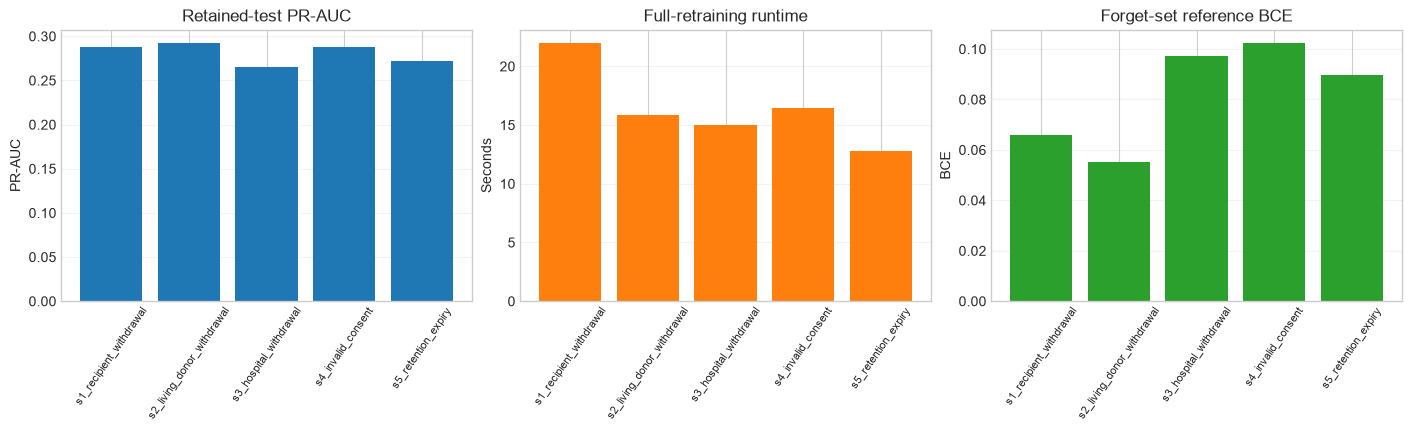

In [47]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
full_rows = utility_metrics.query("model == 'full_retraining'")
axes[0].bar(full_rows["scenario"], full_rows["pr_auc"], color="#1f77b4")
axes[0].set(title="Retained-test PR-AUC", ylabel="PR-AUC")
axes[1].bar(training_summary["scenario"], training_summary["runtime_seconds"], color="#ff7f0e")
axes[1].set(title="Full-retraining runtime", ylabel="Seconds")
axes[2].bar(forget_reference["scenario"], forget_reference["forget_bce"], color="#2ca02c")
axes[2].set(title="Forget-set reference BCE", ylabel="BCE")
for axis in axes:
    axis.tick_params(axis="x", rotation=55, labelsize=8); axis.grid(axis="y", alpha=0.25)
display(figure); plt.close(figure)

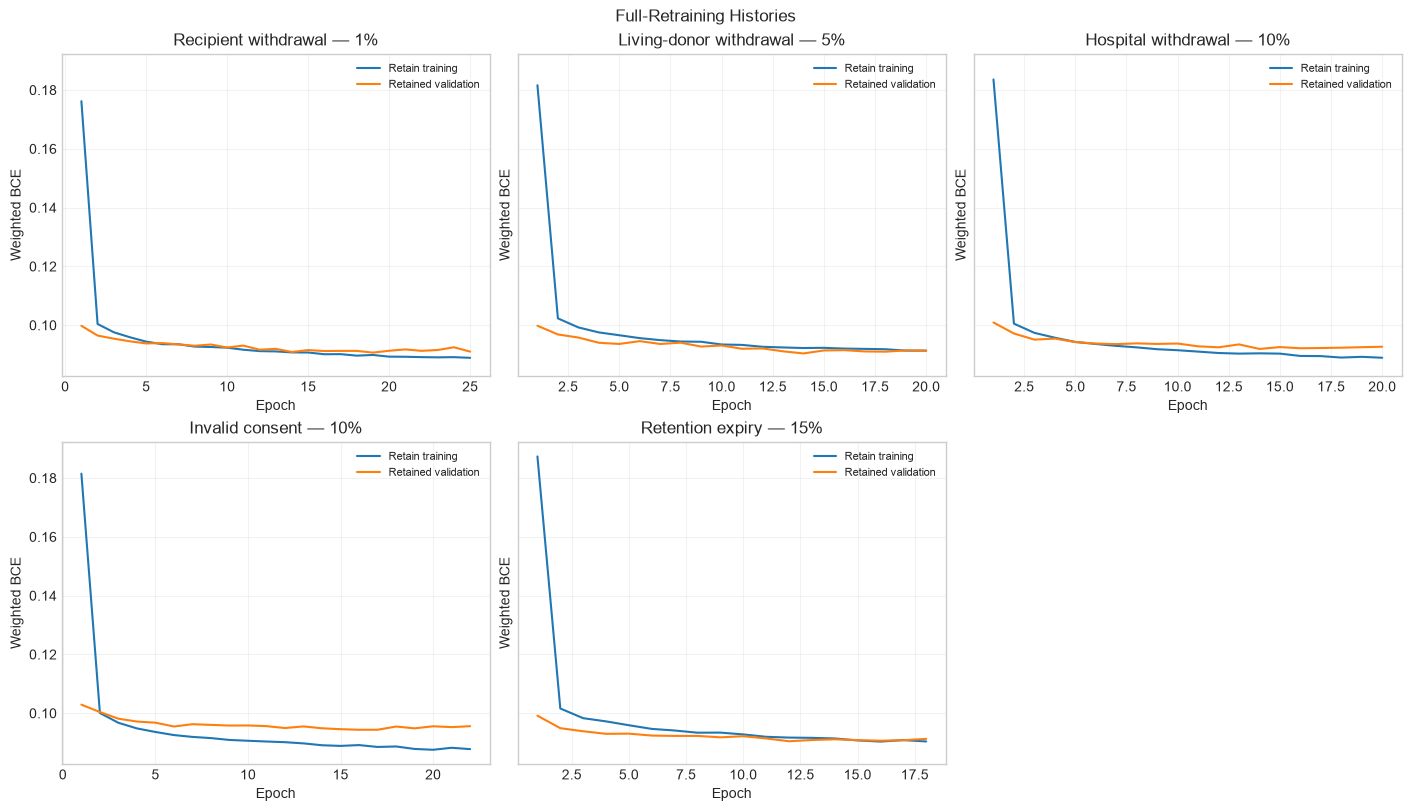

In [48]:
loss_figure, loss_axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True, constrained_layout=True)
for axis, name in zip(loss_axes.ravel(), SCENARIOS):
    history = scenario_runs[name]["history"]
    axis.plot(history["epoch"], history["training_bce"], label="Retain training")
    axis.plot(history["epoch"], history["retained_validation_bce"], label="Retained validation")
    axis.set(title=SCENARIOS[name]["display_name"], xlabel="Epoch", ylabel="Weighted BCE")
    axis.legend(fontsize=8); axis.grid(alpha=0.25)
for axis in loss_axes.ravel()[len(SCENARIOS):]: axis.set_visible(False)
loss_figure.suptitle("Full-Retraining Histories")
display(loss_figure); plt.close(loss_figure)

## 9. Centralised Saving

Models and tables are persisted only after all runs complete. This keeps optimisation separate from artifact handling and makes partial writes less likely.

In [49]:
TABLES = {
    "scenario_summary": (scenario_summary, OUTPUT_DIRS["tables"] / "scenario_summary.csv"),
    "stage_distribution": (stage_distribution, OUTPUT_DIRS["tables"] / "assessment_stage_distribution.csv"),
    "feature_shift": (feature_shift, OUTPUT_DIRS["tables"] / "feature_distribution_shift.csv"),
    "training_summary": (training_summary, OUTPUT_DIRS["tables"] / "training_summary.csv"),
    "utility_metrics": (utility_metrics, OUTPUT_DIRS["metrics"] / "retained_utility_metrics.csv"),
    "forget_reference": (forget_reference, OUTPUT_DIRS["metrics"] / "forget_reference_metrics.csv"),
    "utility_bootstrap": (utility_bootstrap_intervals, OUTPUT_DIRS["metrics"] / "retained_utility_bootstrap_intervals.csv"),
}
for frame, path in TABLES.values(): frame.to_csv(path, index=False)

for name, data in scenario_data.items():
    np.save(OUTPUT_DIRS["indices"] / f"{name}_forget_indices.npy", data["forget_indices"])
    np.save(OUTPUT_DIRS["indices"] / f"{name}_retain_indices.npy", data["retain_indices"])
    scenario_runs[name]["history"].to_csv(OUTPUT_DIRS["histories"] / f"{name}_history.csv", index=False)

In [50]:
MODEL_PATHS, PREPROCESSOR_PATHS = {}, {}
for name, run in scenario_runs.items():
    model_dir = MODEL_ROOT / name; model_dir.mkdir(parents=True, exist_ok=True)
    MODEL_PATHS[name] = model_dir / "model.pt"
    PREPROCESSOR_PATHS[name] = model_dir / "preprocessor.joblib"
    joblib.dump(run["preprocessor"], PREPROCESSOR_PATHS[name])
    payload = {"state_dict": {k: v.detach().cpu() for k, v in run["model"].state_dict().items()},
               "input_dim": len(run["preprocessor"].get_feature_names_out()), "scenario": name,
               "feature_columns": FEATURE_COLUMNS, "threshold": THRESHOLD, "seed": RANDOM_SEED,
               "architecture": ARCHITECTURE, "selected_loss": baseline_checkpoint["selected_loss"],
               "forget_index_hash": index_hash(scenario_data[name]["forget_indices"]),
               "retain_index_hash": index_hash(scenario_data[name]["retain_indices"]),
               "preprocessor_hash": sha256(PREPROCESSOR_PATHS[name])}
    torch.save(payload, MODEL_PATHS[name])

In [51]:
FIGURE_PATHS = {"comparison": OUTPUT_DIRS["figures"] / "full_retraining_comparison.png",
                "histories": OUTPUT_DIRS["figures"] / "full_retraining_histories.png"}
figure.savefig(FIGURE_PATHS["comparison"], dpi=300, bbox_inches="tight")
loss_figure.savefig(FIGURE_PATHS["histories"], dpi=300, bbox_inches="tight")

manifest = {
    "dataset_path": str(DATA_PATH.relative_to(CODE_ROOT)), "dataset_hash": sha256(DATA_PATH),
    "dataset_description": "Entirely synthetic longitudinal kidney-transplant follow-up assessments.",
    "target": TARGET_COLUMN, "feature_list": FEATURE_COLUMNS, "excluded_audit_fields": EXCLUDED_COLUMNS,
    "split_strategy": baseline_manifest["split_strategy"], "group_key": "recipient_id", "seed": RANDOM_SEED,
    "threshold": THRESHOLD, "threshold_label": "fixed_baseline_validation_threshold",
    "loss_choice": baseline_checkpoint["selected_loss"], "preprocessing_policy": "fresh retain-only preprocessor per scenario",
    "optimizer_configuration": {"optimizer": "Adam", "learning_rate": TRAINING_CONFIG["learning_rate"],
                                "weight_decay": TRAINING_CONFIG["weight_decay"]},
    "bootstrap_configuration": {"unit": "recipient_id", "seed": BOOTSTRAP_SEED,
                                "repetitions": BOOTSTRAP_REPETITIONS, "confidence_level": 0.95},
    "deletion_configuration": SCENARIOS,
    "index_hashes": {name: {"forget": index_hash(data["forget_indices"]), "retain": index_hash(data["retain_indices"])}
                     for name, data in scenario_data.items()},
    "runtime_environment": {"python": platform.python_version(), "pandas": pd.__version__,
                            "scikit_learn": sklearn.__version__, "pytorch": torch.__version__, "device": str(DEVICE)},
    "artifact_hashes": {},
}
MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "full_retraining_manifest.json"

In [52]:
# Hash every established output except the manifest that contains the hashes.
artifact_paths = [*[path for _, path in TABLES.values()], *MODEL_PATHS.values(),
                  *PREPROCESSOR_PATHS.values(), *FIGURE_PATHS.values()]
artifact_paths += list(OUTPUT_DIRS["indices"].glob("*.npy")) + list(OUTPUT_DIRS["histories"].glob("*.csv"))
manifest["artifact_hashes"] = {str(path.relative_to(CODE_ROOT)): sha256(path) for path in artifact_paths}
MANIFEST_PATH.write_text(json.dumps(manifest, indent=2))
print(f"Saved {len(artifact_paths)} full-retraining artifacts and manifest.")

Saved 34 full-retraining artifacts and manifest.


## 10. Reload and Verification

Reloading catches path, serialization, and schema failures before approximate methods depend on these references.

In [53]:
def assert_saved_table(path, expected):
    saved = pd.read_csv(path)
    assert saved.columns.tolist() == expected.columns.tolist() and len(saved) == len(expected)
    for column in expected.select_dtypes(include=np.number):
        assert np.allclose(saved[column], expected[column], equal_nan=True)

for frame, path in TABLES.values(): assert_saved_table(path, frame)
for name in SCENARIOS:
    checkpoint = torch.load(MODEL_PATHS[name], map_location="cpu", weights_only=False)
    preprocessor = joblib.load(PREPROCESSOR_PATHS[name])
    assert checkpoint["forget_index_hash"] == index_hash(np.load(OUTPUT_DIRS["indices"] / f"{name}_forget_indices.npy"))
    assert checkpoint["retain_index_hash"] == index_hash(np.load(OUTPUT_DIRS["indices"] / f"{name}_retain_indices.npy"))
    portable = KidneyMLP(checkpoint["input_dim"]); portable.load_state_dict(checkpoint["state_dict"]); portable.eval()
    sample = preprocessor.transform(features.loc[scenario_data[name]["retain_test_indices"]].iloc[:8]).astype(np.float32)
    with torch.no_grad(): assert torch.isfinite(portable(torch.tensor(sample))).all()
assert json.loads(MANIFEST_PATH.read_text()) == manifest
print("All full-retraining models, preprocessors, indices, tables and figures reloaded successfully.")

All full-retraining models, preprocessors, indices, tables and figures reloaded successfully.


## 11. Final Summary

In [54]:
display(Markdown(
    "- Five entity-complete deletion scenarios contain exactly **420, 2,100, 4,200, 4,200 and 6,300** training rows.\n"
    "- Every forget/retain pair is disjoint and reconstructs the original 42,000-row training partition.\n"
    "- Each scenario has one fresh seed-42 model and retain-only preprocessor selected by retained-validation BCE.\n"
    f"- All utility results use the unchanged experimental baseline threshold **{THRESHOLD:.2f}**.\n"
    "- Full retraining is a deterministic behavioural reference, not proof of regulatory compliance or clinical validity."
))

- Five entity-complete deletion scenarios contain exactly **420, 2,100, 4,200, 4,200 and 6,300** training rows.
- Every forget/retain pair is disjoint and reconstructs the original 42,000-row training partition.
- Each scenario has one fresh seed-42 model and retain-only preprocessor selected by retained-validation BCE.
- All utility results use the unchanged experimental baseline threshold **0.07**.
- Full retraining is a deterministic behavioural reference, not proof of regulatory compliance or clinical validity.